# WFS controls for operation at ALS beamline 5.3.1

Authors: khchan@lbl.gov, francisho@lbl.gov, awojdyla@lbl.gov, walangrizolli@lbl.gov

We added capture of the beam a the sample. It doesn't quite work but we're close.
We want to acquire a nice grid scanbender/energy without any binning.

We want to add relevant metadata (exposure time , pixel size/camera model, binning) so that we can scale data accordingly (effective flux, effective size)

# SETUP 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

from tiled.client import from_uri

import wfs_live as wfl

## Setting up epics/ophyd/bluesky/tiled

In [ ]:
from ophyd import EpicsMotor
Obender = EpicsMotor('bl531_esp300:m101_bend_um', name='bender_um')
Obender.low_limit_travel.set(-2000)

# here is the wrapper
#from h01 import mono_energy

In [ ]:
import sys
sys.path.append('/home/bl531/python/nabla/')
from nabla.nophyd import MonoEnergy, BaslerDetector, BCSMotor

In [ ]:
mono_energy = MonoEnergy('', name='mono_energy')  # Empty prefix since motor has full PV

In [ ]:
BASLER_FILES_ROOT = "/mnt/data531"
BASLER_5472_IMAGE_DIR = "scans/%Y/%m/%d/basler5472"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs
BASLER_2448_IMAGE_DIR = "scans/%Y/%m/%d/basler2448"   # e.g. "20251113_test/%Y/%m/%d" if you want date subdirs

try:
    basler_5472 = BaslerDetector(
        "BL531acA5427:",
        name="basler_5472",
        image_dir=BASLER_5472_IMAGE_DIR,
    )

    # Stage signals — set before each acquisition, restored after
    basler_5472.cam.stage_sigs['image_mode']    = 'Single'
    basler_5472.cam.stage_sigs['num_images']    = 1
    basler_5472.cam.stage_sigs['acquire_time']  = 2
    basler_5472.cam.stage_sigs['acquire_period'] = 0.5

    basler_5472.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    basler_5472.tiff.stage_sigs['enable']        = 1
    basler_5472.tiff.stage_sigs['auto_save']     = 'Yes'
    basler_5472.tiff.stage_sigs['file_write_mode'] = 'Single'

    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    basler_5472.read_attrs      = ['tiff']
    basler_5472.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531acA5427:'")

try:
    basler_2448 = BaslerDetector(
        "BL531a2A2448:",
        name="basler_2448",
        image_dir=BASLER_2448_IMAGE_DIR,
    )

    # Stage signals — set before each acquisition, restored after
    basler_2448.cam.stage_sigs['image_mode']    = 'Single'
    basler_2448.cam.stage_sigs['num_images']    = 1
    basler_2448.cam.stage_sigs['acquire_time']  = 1
    basler_2448.cam.stage_sigs['acquire_period'] = 1.1
    # basler_2448.cam.stage_sigs['trigger_mode'] = 'Off' 
    basler_2448.cam.stage_sigs['array_callbacks'] = 1
    # basler_2448.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    # basler_2448.tiff.stage_sigs['enable']        = 1
    # basler_2448.tiff.stage_sigs['auto_save']     = 'Yes'
    # basler_2448.tiff.stage_sigs['file_write_mode'] = 'Single'
    
    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    # basler_2448.read_attrs      = ['tiff']
    # basler_2448.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531a2A2448:'")

In [ ]:
import bcs_tcp

# ============================================================
# BCS TCP connection (same as your existing setup)
# ============================================================

ALSU_BOSS_IP = "131.243.80.251"
(host_ip_addr, host_port, host_timeout) = (ALSU_BOSS_IP, 55000, 5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Motor id strings (same as before)
bcs_id_linear = 'Galil x.20 A'
bcs_id_rotary = 'Galil x.20 B'

# Quick sanity check
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print(f'linear stage position is {pos_lin_mm} mm')

# ============================================================
# Instantiate BCSMotor ophyd objects
# ============================================================

bcs_linear_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_linear,
    settle_time=0.5,
    tolerance=0.001,
    name='bcs_linear_motor',
)

bcs_rotary_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_rotary,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_rotary_motor',
)

# ============================================================
# Quick checks
# ============================================================

print(f'Linear motor position : {bcs_linear_motor.position} mm')
print(f'Rotary motor position : {bcs_rotary_motor.position} deg')
print(bcs_linear_motor)
print(bcs_rotary_motor)

In [ ]:
# The queue server must include the "keep_re" parameter which prevents the RE in this startup script from being overwritten

from bluesky import RunEngine

RE = RunEngine({})

from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri

#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)
tw = TiledWriter(tiled_client, batch_size=1)
## doesnt work yet because the central server is not configured to accept the resource documents with the local file paths. need to patch the resource documents to replace the local path prefix with the central path prefix before sending to central tiled server.

central_tiled_api_key = os.getenv("CENTRAL_API_KEY")
if not central_tiled_api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

central_tiled_client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw", api_key=central_tiled_api_key)


LOCAL_PATH_PREFIX = "mnt/data531"
CENTRAL_PATH_PREFIX = "/global/beegfs/beamlines/bl531/raw"

def patch_ride_filenames(doc: dict):
    """
    a TiledWriter will be sending documents to the central Tiled server.
    For resource documents, we want to patch resource_path;
    Add CENTRAL_PATH_PREFIX in place of LOCAL_PATH_PREFIX as the root key
    Strip LOCAL_PATH_PREFIX from the beginning of resource_path, if it exists
    :param doc_name: Description
    :type doc_name: str
    :param doc: Description
    :type doc: dict
    """    
    resource_path = doc.get("resource_path", "")
    if resource_path.startswith(LOCAL_PATH_PREFIX):
        # Strip LOCAL_PATH_PREFIX and prepend CENTRAL_PATH_PREFIX
        relative_path = resource_path[len(LOCAL_PATH_PREFIX):].lstrip("/")
        new_resource_path = os.path.join(CENTRAL_PATH_PREFIX, relative_path)
        doc["resource_path"] = new_resource_path
        #print(f"Patched resource_path: {resource_path} -> {new_resource_path}")
    return doc

central_tiled_writer = TiledWriter(central_tiled_client, batch_size=1, patches={"resource": patch_ride_filenames})
# uncomment this to connect to central tiled server
# RE.subscribe(central_tiled_writer)

RE.subscribe(tw)

bec = BestEffortCallback()

bec.disable_plots()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

# add 'baseline' stream with start/stop position of ophyd devices passed into 'sd'
from bluesky.preprocessors import SupplementalData
sd = SupplementalData()
RE.preprocessors.append(sd)
sd.baseline = []
if sd:
#    sd.baseline = [mono_energy, Obender, bcs_linear_motor, basler_5472.cam.stage_sigs['acquire_time']] #for now just adding these two. add more as needed.
    sd.baseline = [mono_energy, Obender, bcs_linear_motor] #for now just adding these two. add more as needed.


## Check data acquisition

In [ ]:
from bluesky import plans as bp
sd.baseline = [mono_energy, Obender, bcs_linear_motor]

# cam_model = basler_5472.cam.model.read()['basler_5472_cam_model']['value']
objective_model = "Mitutoyo Plan Apo HR 5X"
# exp_time_s = basler_5472.cam.stage_sigs['acquire_time']
pixel_size_um = 2.4
binx = basler_5472.cam.bin_x.read()['basler_5472_cam_bin_x']['value']
biny = basler_5472.cam.bin_y.read()['basler_5472_cam_bin_y']['value']
objective_mag = 5
effective_pixel_size_um = pixel_size_um * binx / objective_mag

# md={"exposure time [s]": f"{exp_time_s}", 
#     "pixel size [um]": f"{pixel_size_um}", 
#     "binning": f"{binx}x{biny}", 
#     "effective pixel size [um]": f"{effective_pixel_size_um}", 
#     "camera model": f"{cam_model}", 
#     "objective model": f"{objective_model}"
# }
md = {
    'pixel size [um]': f"{pixel_size_um}", 
    'binning': f"{binx}x{biny}",
    'effective pixel size [um]': f"{effective_pixel_size_um}", 
    'objective model': f"{objective_model}",   
}

uid = RE(bp.count([basler_5472], num=1, md = md))

In [ ]:
db = tiled_client[uid]

# Metadata: Hardware-reported; stored in config
cam   = db['primary'].metadata['configuration']['basler_5472']['data']
exp_time_s   = cam['basler_5472_cam_acquire_time']
camera_model = cam['basler_5472_cam_model']

# Descriptive (from md; .get())
start = db.metadata['start']
pixel_size_um           = start.get('pixel size [um]')
binning                 = start.get('binning')
effective_pixel_size_um = start.get('effective pixel size [um]')
objective_model         = start.get('objective model')

print(f"Camera:          {camera_model}")
print(f"Objective:       {objective_model}")
print(f"Pixel size:      {pixel_size_um} µm  (binning: {binning})")
print(f"Effective pixel: {effective_pixel_size_um} µm")
print(f"Exposure time:   {exp_time_s} s")

In [ ]:
# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()
bender_um = db['baseline']['bender_um'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
print(f"Mono energy (eV): {energy_eV}")
print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()     
# energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
# print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
# print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")


In [ ]:
plt.figure(figsize=(20, 8))
plt.imshow(images[0, :, :].T, cmap='hot')
plt.title('WFS data')
plt.show()

In [ ]:
plt.figure(figsize=(20, 8))
plt.imshow(images[0, :, :].T, cmap='hot')
plt.title('WFS data')
plt.show()

# SCANS

## Trials


### Count

In [ ]:
uid = RE(bp.count([basler_5472], num=1, md = md))

### Energy and bender scans

In [ ]:
uid_01 = RE(bp.scan([basler_5472], mono_energy, 7500, 9500, 11))

In [ ]:
db = tiled_client[uid_01]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
bender_um = db['baseline']['bender_um'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()     
energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")


In [ ]:
idx = 5

plt.figure(figsize=(8, 3))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx={idx}   E={energy_eV[idx]:.0f} eV   bender={bender_um[0]:.0f} µm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [ ]:
uid_02 = RE(bp.scan([basler_5472], Obender, -2000, -1400, 13))

In [ ]:
db = tiled_client[uid_02]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
# bender_um = db['baseline']['bender_um'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()     
# energy_eV = db['primary']['mono_energy_energy_eV'].read() 
bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
# print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
# print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")


In [ ]:
idx = 10

plt.figure(figsize=(8, 3))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx={idx}   E={energy_eV[0]:.0f} eV   bender={bender_um[idx]:.0f} µm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [ ]:
mono_energy.move(8000)
Obender.move(-2000)

In [ ]:
print(mono_energy.get())
print(Obender.get())
print(bcs_linear_motor.get())

### Chip translation scan

In [ ]:
uid_03 = RE(bp.scan([basler_5472], bcs_linear_motor, 4.400, 4.410, 11))

In [ ]:
db = tiled_client[uid_03]

# Metadata
# wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
bender_um = db['baseline']['bender_um'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()

# print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
print(f"Mono energy (eV): {energy_eV}")
print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
# energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
# print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
# print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")
print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
print(f"       shape: {wfs_chip_pos_mm.shape}")

In [ ]:
idx = 10

plt.figure(figsize=(8, 3))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx={idx}   E={energy_eV[0]:.0f} eV   bender={bender_um[0]:.0f} µm   chip_pos={wfs_chip_pos_mm[idx]:.3f} mm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

### Grid scan

In [ ]:
from bluesky.plans import grid_scan

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_04 = RE(grid_scan([basler_5472], mono_energy, 7500, 8500, 3, Obender, -2000, -1400, 4, snake_axes=False, md=md))  

In [ ]:
db = tiled_client[uid_04]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
# bender_um = db['baseline']['bender_um'].read()
# energy_eV = db['baseline']['mono_energy_energy_eV'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
# print(f"Mono energy (eV): {energy_eV}")
# print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
# wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
energy_eV = db['primary']['mono_energy_energy_eV'].read() 
bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")
# print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
# print(f"       shape: {wfs_chip_pos_mm.shape}")

In [ ]:
idx = 11

plt.figure(figsize=(8, 3))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx={idx}   E={energy_eV[idx]:.0f} eV   bender={bender_um[idx]:.0f} µm   chip_pos={wfs_chip_pos_mm[0]:.3f} mm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

## Measurements



In [ ]:
from bluesky.plans import grid_scan

mono_energy.move(8000)
Obender.move(-2000)

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_05 = RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -2000, -1400, 13, snake_axes=False, md=md))  

In [ ]:
db = tiled_client[uid_05]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
# bender_um = db['baseline']['bender_um'].read()
# energy_eV = db['baseline']['mono_energy_energy_eV'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
# print(f"Mono energy (eV): {energy_eV}")
# print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
# wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
energy_eV = db['primary']['mono_energy_energy_eV'].read() 
bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")
# print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
# print(f"       shape: {wfs_chip_pos_mm.shape}")

In [ ]:
idx = 131

plt.figure(figsize=(8, 3))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx={idx}   E={energy_eV[idx]:.0f} eV   bender={bender_um[idx]:.0f} µm   chip_pos={wfs_chip_pos_mm[0]:.3f} mm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [ ]:

mono_energy.move(8000)
Obender.move(-2000)

In [ ]:
from bluesky.plans import grid_scan

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_06 = RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -400, 0, 9, snake_axes=False, md=md))  

In [ ]:
db = tiled_client[uid_06]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
# bender_um = db['baseline']['bender_um'].read()
# energy_eV = db['baseline']['mono_energy_energy_eV'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
# print(f"Mono energy (eV): {energy_eV}")
# print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
# wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
energy_eV = db['primary']['mono_energy_energy_eV'].read() 
bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
print(f"       shape: {energy_eV.shape}")
print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
print(f"       shape: {bender_um.shape}")
# print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
# print(f"       shape: {wfs_chip_pos_mm.shape}")

In [ ]:
mono_energy.move(8000)
Obender.move(-2000)

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_07 = RE(bp.scan([basler_5472], bcs_linear_motor, 4.410, 4.600, 191))

uid_08 = RE(bp.scan([basler_5472], bcs_linear_motor, 5.500, 5.700, 201))

In [ ]:
db = tiled_client[uid_07]

# Metadata
# wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
bender_um = db['baseline']['bender_um'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()

# print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
print(f"Mono energy (eV): {energy_eV}")
print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
# energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
# print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
# print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")
print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
print(f"       shape: {wfs_chip_pos_mm.shape}")

In [ ]:
idx = 190

plt.figure(figsize=(8, 3))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx={idx}   E={energy_eV[0]:.0f} eV   bender={bender_um[0]:.0f} µm   chip_pos={wfs_chip_pos_mm[idx]:.3f} mm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [ ]:
uid_09 = RE(bp.count([basler_5472], num=1, md = md))

In [ ]:
db = tiled_client[uid_09]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
bender_um = db['baseline']['bender_um'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
print(f"Mono energy (eV): {energy_eV}")
print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
# wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
# energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
# print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
# print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")
# print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
# print(f"       shape: {wfs_chip_pos_mm.shape}")

In [ ]:
plt.figure(figsize=(8, 3))
plt.imshow(images[0].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx=0   E={energy_eV[0]:.0f} eV   bender={bender_um[0]:.0f} µm   chip_pos={wfs_chip_pos_mm[0]:.3f} mm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [ ]:
mono_energy.move(8000)
Obender.move(-2000)

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_10 = RE(bp.scan([basler_5472], bcs_linear_motor, 7.400, 7.410, 2))

In [ ]:
db = tiled_client[uid_10]

# Metadata
# wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
bender_um = db['baseline']['bender_um'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()

# print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
print(f"Mono energy (eV): {energy_eV}")
print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
# energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
# print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
# print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")
print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
print(f"       shape: {wfs_chip_pos_mm.shape}")

In [ ]:
plt.figure(figsize=(8, 3))
plt.imshow(images[0].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx=0   E={energy_eV[0]:.0f} eV   bender={bender_um[0]:.0f} µm   chip_pos={wfs_chip_pos_mm[0]:.3f} mm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [ ]:
from bluesky.plans import grid_scan

mono_energy.move(8000)
Obender.move(-2000)

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_11 = RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -2000, -1400, 13, snake_axes=False, md=md))  

mono_energy.move(8000)
Obender.move(-2000)

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_12 = RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -400, 0, 9, snake_axes=False, md=md))

Forgot to move `bcs_linear_motor` further up. 

In [ ]:
mono_energy.move(8000)
Obender.move(-2000)

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_13 = RE(bp.scan([basler_5472], bcs_linear_motor, 7.899, 7.900, 2))

In [ ]:
db = tiled_client[uid_13]

# Metadata
# wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
bender_um = db['baseline']['bender_um'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()  

idx = 1

plt.figure(figsize=(12, 5))
plt.imshow(images[idx].T, cmap='hot', interpolation='nearest', vmax=4000)
plt.title(f'idx=0   E={energy_eV[0]:.0f} eV   bender={bender_um[0]:.0f} µm   chip_pos={wfs_chip_pos_mm[idx]:.3f} mm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

In [ ]:
from bluesky.plans import grid_scan

mono_energy.move(8000)
Obender.move(-2000)

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_14 = RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -2000, -1400, 13, snake_axes=False, md=md))  

mono_energy.move(8000)
Obender.move(-2000)

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_15 = RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -400, 0, 9, snake_axes=False, md=md))

In [ ]:
mono_energy.move(8000)
Obender.move(-2000)

print(f"Energy setpoint: {mono_energy.get().energy_eV.setpoint:.1f} eV (readback: {mono_energy.get().energy_eV.setpoint:.1f} eV)")
print(f"Bender setpoint: {Obender.get().user_setpoint:.0f} µm (readback: {Obender.get().user_readback:.0f} µm)")
print(f"BCS linear motor: {bcs_linear_motor.get():.3f} mm")

uid_16 = RE(bp.scan([basler_5472], bcs_linear_motor, 7.901, 8.100, 200))

uid_17 = RE(bp.scan([basler_5472], bcs_linear_motor, 8.900, 9.100, 201))

In [ ]:
uid = RE(bp.count([basler_5472], num=1, md = md))

In [ ]:
db = tiled_client[uid]

# Metadata
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()
bender_um = db['baseline']['bender_um'].read()
energy_eV = db['baseline']['mono_energy_energy_eV'].read()

print(f"WFS chip position (mm): {wfs_chip_pos_mm}")
print(f"Mono energy (eV): {energy_eV}")
print(f"Bender position (µm): {bender_um}")

# Data arrays (slow)
images    = db['primary']['basler_5472_image'].read()  
# wfs_chip_pos_mm = db['primary']['bcs_linear_motor'].read()   
# energy_eV = db['primary']['mono_energy_energy_eV'].read() 
# bender_um = db['primary']['bender_um'].read() 

# Print summaries
print(f"\nImages shape: {images.shape}  (n_frames × height × width)")
# print(f"Energy range: {energy_eV.min():.1f} – {energy_eV.max():.1f} eV")
# print(f"       shape: {energy_eV.shape}")
# print(f"Bender range: {bender_um.min():.1f} – {bender_um.max():.1f} µm")
# print(f"       shape: {bender_um.shape}")
# print(f"WFS chip position range: {wfs_chip_pos_mm.min():.3f} – {wfs_chip_pos_mm.max():.3f} mm")
# print(f"       shape: {wfs_chip_pos_mm.shape}")

In [ ]:
plt.figure(figsize=(8, 3))
plt.imshow(images[0].T, cmap='hot', interpolation='nearest', vmax=100)
plt.title(f'idx=0   E={energy_eV[0]:.0f} eV   bender={bender_um[0]:.0f} µm   chip_pos={wfs_chip_pos_mm[0]:.3f} mm', fontsize=12)
plt.xlabel('y [pixels]')
plt.ylabel('x [pixels]')
plt.colorbar(label='Intensity [counts]')
plt.tight_layout()
plt.show()

## Reconstructions

### Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tiled.client import from_uri
import os


In [8]:
import monoplus as mp
import wfs_live as wfl


In [21]:
import warnings
warnings.simplefilter('always', RuntimeWarning)

In [3]:
# --- Server connection ---
api_key_path = "/Users/francisho/Documents/TILED_SINGLE_USER_API_KEY.txt"   # Change this path to where your API key is stored 

with open(api_key_path, "r") as f:
    api_key = f.read().strip()

if not api_key:
    raise ValueError("API key file is empty or not found.")

tiled_client = from_uri("http://131.243.80.226:8000", api_key=api_key)

### WF measured by chip 1

Data: `uid_05 = RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -2000, -1400, 13, snake_axes=False, md=md))`
- uid_05 = '4adb81df-534d-4fc9-8590-ab1a449e5b54'
- d = 7 mm (or 4.4 mm)

In [ ]:
# --- Cell A: uid_05 load + ROI eyeball ---
db = tiled_client['4adb81df-534d-4fc9-8590-ab1a449e5b54']
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

print(f"images: {images.shape}")
print(f"E range:      {energy_eV.min():.0f} – {energy_eV.max():.0f} eV")
print(f"bender range: {bender_um.min():.0f} – {bender_um.max():.0f} µm")


KeyboardInterrupt: 

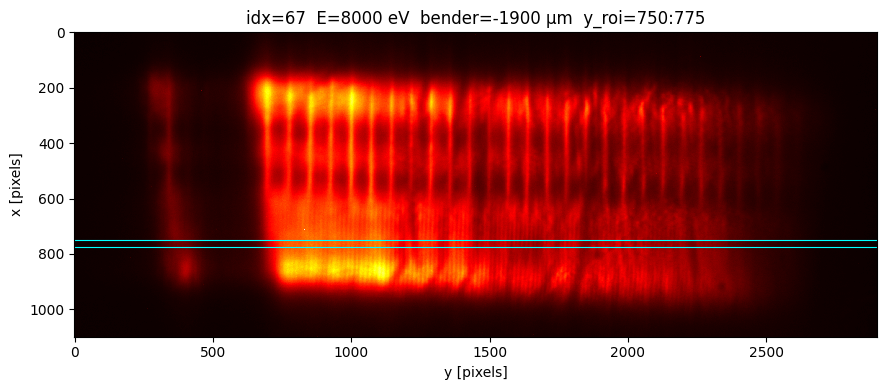

In [ ]:
idx   = 67                  # center-ish of 11×13 (E, bender) grid
y_roi = slice(750, 775)     # adjust by eye to land on the fringe band

img = images[idx]
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(img.T, cmap='hot', interpolation='nearest', vmax=4000)
ax.axhline(y_roi.start, color='cyan', lw=0.8)
ax.axhline(y_roi.stop,  color='cyan', lw=0.8)
ax.set_title(f'idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm  '
             f'y_roi={y_roi.start}:{y_roi.stop}')
ax.set_xlabel('y [pixels]'); ax.set_ylabel('x [pixels]')
plt.tight_layout(); plt.show()

In [33]:
# --- Cell B: physical parameters ---
effective_pixel_size_um = float(db.metadata['start']['effective pixel size [um]'])
dx_m            = effective_pixel_size_um * 1e-6
grating_pitch_m = 7e-6          # candidates: 4.4, 4.9, 5.5, 6.2, 7 µm — start with 7
z_gd_m          = 0.3
wavelength_m_arr = wfl.energy_eV_to_wavelength_m(energy_eV)

print(f"dx (effective): {dx_m*1e6:.3f} µm")
print(f"grating pitch:  {grating_pitch_m*1e6:.1f} µm  (assumed)")
print(f"z_gd:           {z_gd_m*1e3:.0f} mm")
print(f"λ range:        {wavelength_m_arr.min()*1e9:.4f} – {wavelength_m_arr.max()*1e9:.4f} nm")

dx (effective): 0.480 µm
grating pitch:  7.0 µm  (assumed)
z_gd:           300 mm
λ range:        0.1378 – 0.1771 nm


[  ok]  λ=0.15nm  k_peak=134.3 cyc/mm  r_DC=149.4  SNR=36.7  f_pred=-5.34m  RMS_W=9.2nm  RMS_resid=0.063nm  z_focus=-5.56m(fwhm_min)  RMS@focus=0.063nm


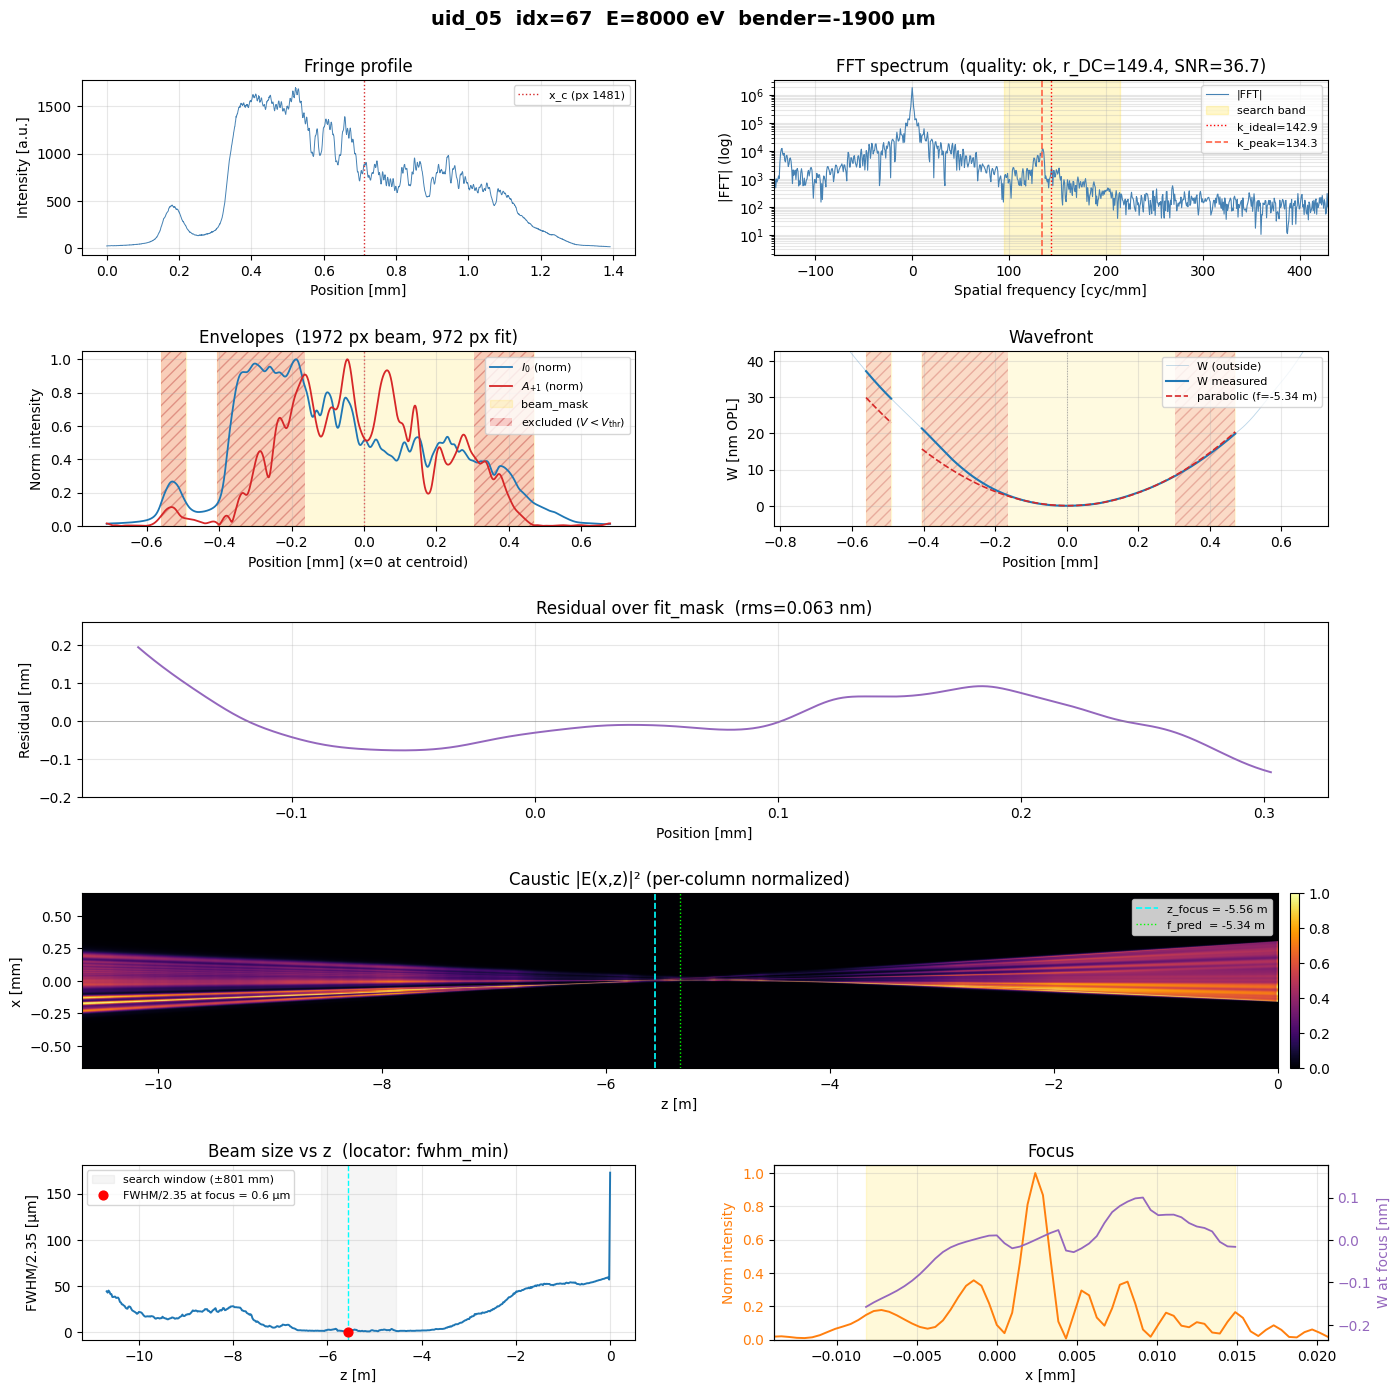

In [36]:
# --- Cell C: single-frame reconstruction ---
# y_roi = slice(750, 800)

result = wfl.quick_look(
    images[idx], dx_m, grating_pitch_m, wavelength_m_arr[idx], z_gd_m,
    y_roi=y_roi, axis=1, 
    propagate=True,
    caustic_amplitude='gated', V_threshold=0.5,
    fill_gaps=False,
    title=f'uid_05  idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm',
)


### WF measured by chip 2 

Data: `uid_15 = RE(grid_scan([basler_5472], mono_energy, 7000, 9000, 11, Obender, -400, 0, 9, snake_axes=False, md=md))`
- uid_15 = '5dbef69f-1e5b-43f3-8950-7118053075a1'
- d = 6.2 mm (or 4.9 mm)

In [37]:
# --- Cell A: uid_15 load + ROI eyeball ---
db = tiled_client['5dbef69f-1e5b-43f3-8950-7118053075a1']
images    = db['primary']['basler_5472_image'].read()
energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

print(f"images: {images.shape}")
print(f"E range:      {energy_eV.min():.0f} – {energy_eV.max():.0f} eV")
print(f"bender range: {bender_um.min():.0f} – {bender_um.max():.0f} µm")


images: (143, 2900, 1100)
E range:      7000 – 9000 eV
bender range: -2000 – -1400 µm


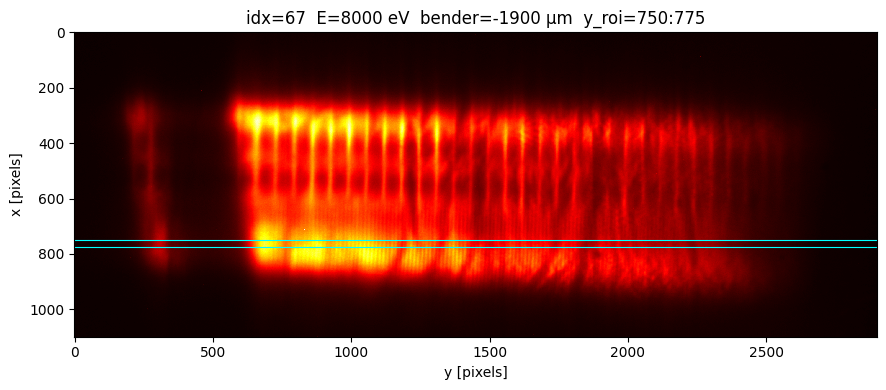

In [40]:
idx   = 67                  # center-ish of 11×13 (E, bender) grid
y_roi = slice(750, 775)     # adjust by eye to land on the fringe band

img = images[idx]
fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(img.T, cmap='hot', interpolation='nearest', vmax=3000)
ax.axhline(y_roi.start, color='cyan', lw=0.8)
ax.axhline(y_roi.stop,  color='cyan', lw=0.8)
ax.set_title(f'idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm  '
             f'y_roi={y_roi.start}:{y_roi.stop}')
ax.set_xlabel('y [pixels]'); ax.set_ylabel('x [pixels]')
plt.tight_layout(); plt.show()

In [41]:
# --- Cell B: physical parameters ---
effective_pixel_size_um = float(db.metadata['start']['effective pixel size [um]'])
dx_m            = effective_pixel_size_um * 1e-6
grating_pitch_m = 6.2e-6          # candidates: 4.4, 4.9, 5.5, 6.2, 7 µm — start with 7
z_gd_m          = 0.3
wavelength_m_arr = wfl.energy_eV_to_wavelength_m(energy_eV)

print(f"dx (effective): {dx_m*1e6:.3f} µm")
print(f"grating pitch:  {grating_pitch_m*1e6:.1f} µm  (assumed)")
print(f"z_gd:           {z_gd_m*1e3:.0f} mm")
print(f"λ range:        {wavelength_m_arr.min()*1e9:.4f} – {wavelength_m_arr.max()*1e9:.4f} nm")

dx (effective): 0.480 µm
grating pitch:  6.2 µm  (assumed)
z_gd:           300 mm
λ range:        0.1378 – 0.1771 nm


[  ok]  λ=0.15nm  k_peak=150.1 cyc/mm  r_DC=199.3  SNR=58.0  f_pred=-4.78m  RMS_W=10.1nm  RMS_resid=0.083nm  z_focus=-5.14m(fwhm_min)  RMS@focus=0.074nm


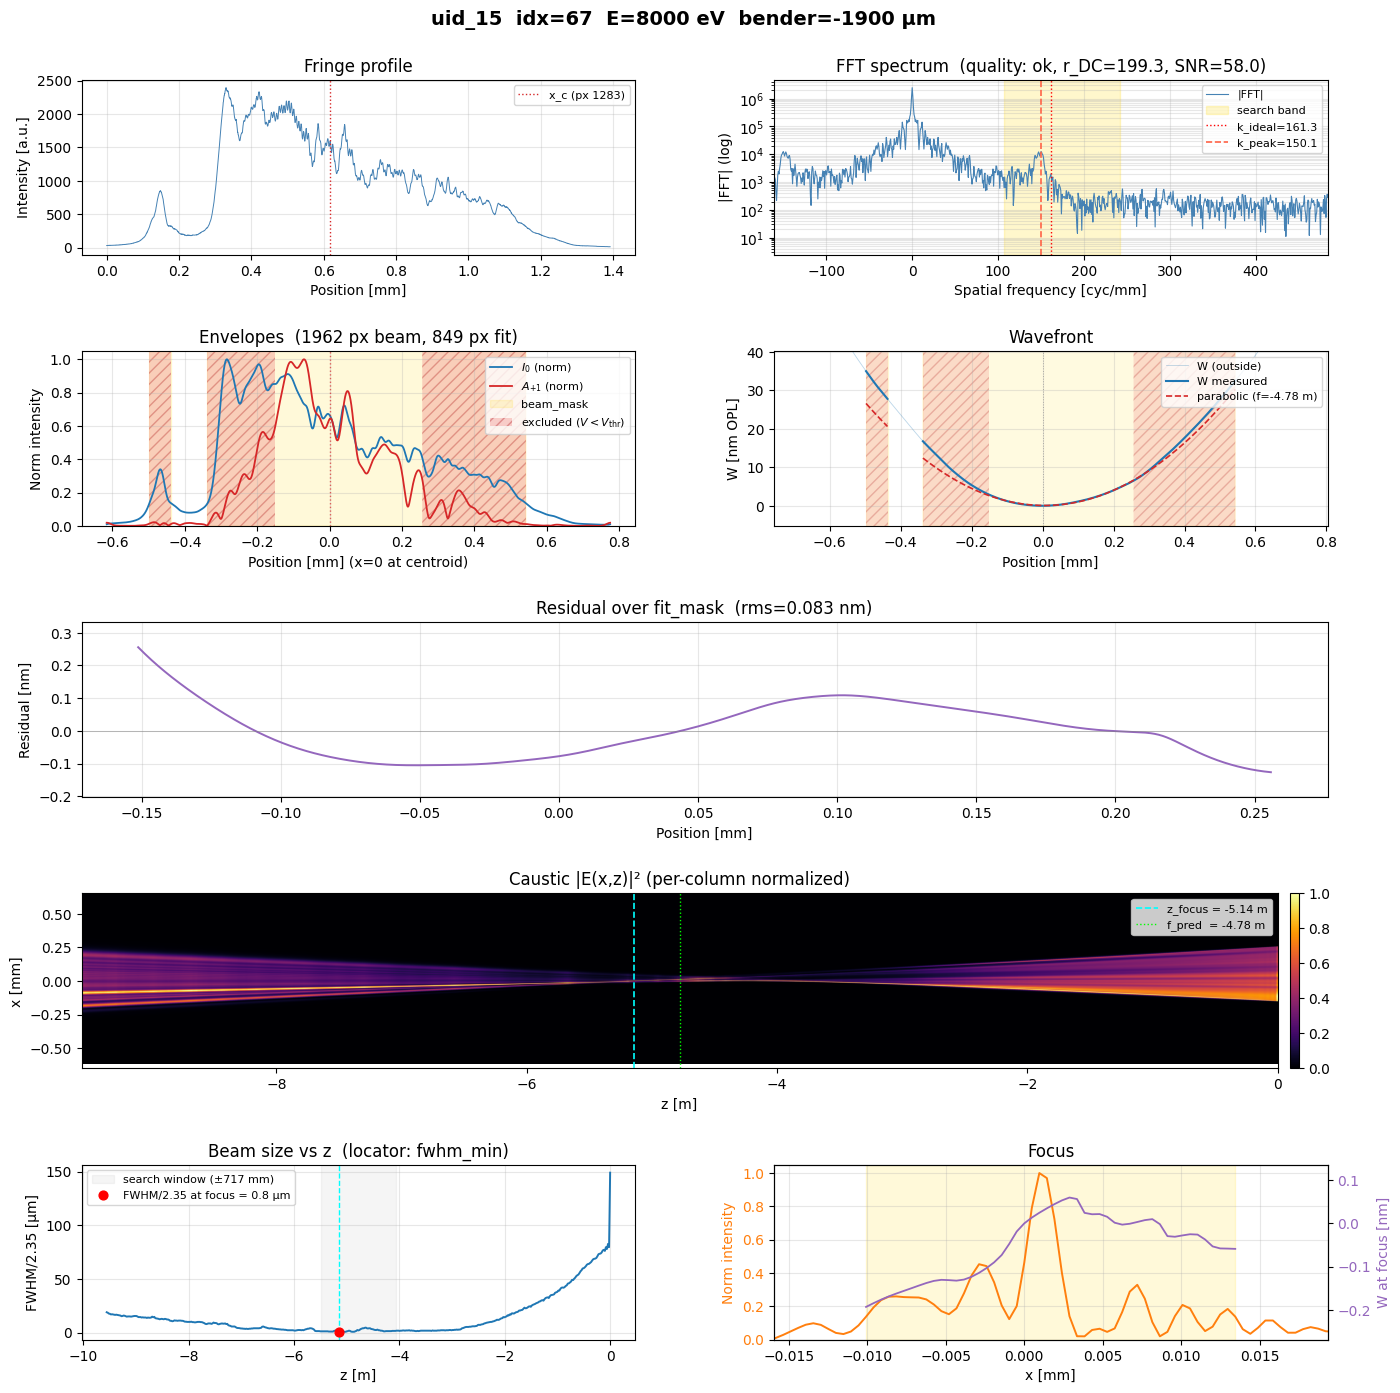

In [44]:
# --- Cell C: single-frame reconstruction ---
# y_roi = slice(750, 800)

result = wfl.quick_look(
    images[idx], dx_m, grating_pitch_m, wavelength_m_arr[idx], z_gd_m,
    y_roi=y_roi, axis=1, 
    propagate=True,
    caustic_amplitude='gated', V_threshold=0.5,
    fill_gaps=False,
    title=f'uid_15  idx={idx}  E={energy_eV[idx]:.0f} eV  bender={bender_um[idx]:.0f} µm',
)
